In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

print(tf.__version__)

2.20.0


In [2]:
vocab = {
    "movie": 0,
    "actor": 1,
    "good": 2,
    "bad": 3,
    "not": 4
}

index_to_word = {v: k for k, v in vocab.items()}

vocab_size = len(vocab)
input_features = vocab_size
timesteps = 3
hidden_units = 3

vocab_size, input_features, timesteps, hidden_units

(5, 5, 3, 3)

In [3]:
def one_hot(index, size):
    vector = np.zeros(size, dtype=np.float32)
    vector[index] = 1.0
    return vector

encoded_words = {
    word: one_hot(index, vocab_size)
    for word, index in vocab.items()
}

encoded_words

{'movie': array([1., 0., 0., 0., 0.], dtype=float32),
 'actor': array([0., 1., 0., 0., 0.], dtype=float32),
 'good': array([0., 0., 1., 0., 0.], dtype=float32),
 'bad': array([0., 0., 0., 1., 0.], dtype=float32),
 'not': array([0., 0., 0., 0., 1.], dtype=float32)}

In [4]:
reviews = [
    ["movie", "good", "actor"],
    ["movie", "bad", "actor"],
    ["not", "good", "movie"],
    ["movie", "not", "bad"],
    ["good", "movie", "actor"],
    ["bad", "movie", "actor"]
]

labels = np.array([1, 0, 1, 0, 1, 0], dtype=np.float32)

X = np.array(
    [
        [encoded_words[word] for word in review]
        for review in reviews
    ],
    dtype=np.float32
)

X.shape, labels.shape

((6, 3, 5), (6,))

In [5]:
print("Vocabulary size:", vocab_size)
print("Time steps:", timesteps)
print("Input features:", input_features)
print("Hidden units:", hidden_units)
print("X shape:", X.shape)

for i, review in enumerate(reviews):
    print(i, review, labels[i])

Vocabulary size: 5
Time steps: 3
Input features: 5
Hidden units: 3
X shape: (6, 3, 5)
0 ['movie', 'good', 'actor'] 1.0
1 ['movie', 'bad', 'actor'] 0.0
2 ['not', 'good', 'movie'] 1.0
3 ['movie', 'not', 'bad'] 0.0
4 ['good', 'movie', 'actor'] 1.0
5 ['bad', 'movie', 'actor'] 0.0


In [6]:
sample = X[0]

for t in range(timesteps):
    print("t =", t + 1)
    print("word =", reviews[0][t])
    print("x_t =", sample[t])

t = 1
word = movie
x_t = [1. 0. 0. 0. 0.]
t = 2
word = good
x_t = [0. 0. 1. 0. 0.]
t = 3
word = actor
x_t = [0. 1. 0. 0. 0.]


In [7]:
W_xh = np.array([
    [0.20, -0.10, 0.30],
    [0.40, 0.10, -0.20],
    [-0.30, 0.50, 0.20],
    [0.10, -0.40, 0.30],
    [0.20, 0.30, -0.10]
], dtype=np.float32)

W_hh = np.array([
    [0.10, 0.20, -0.10],
    [-0.20, 0.30, 0.40],
    [0.30, -0.20, 0.20]
], dtype=np.float32)

b_h = np.array([0.10, 0.00, -0.10], dtype=np.float32)

W_hy = np.array([
    [0.30],
    [-0.20],
    [0.40]
], dtype=np.float32)

b_y = np.array([0.10], dtype=np.float32)

W_xh.shape, W_hh.shape, b_h.shape, W_hy.shape, b_y.shape

((5, 3), (3, 3), (3,), (3, 1), (1,))

In [8]:
total_parameters = (
    W_xh.size +
    W_hh.size +
    b_h.size +
    W_hy.size +
    b_y.size
)

total_parameters

31

In [9]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def rnn_step(x_t, h_prev):
    hidden_linear = x_t @ W_xh + h_prev @ W_hh + b_h
    h_t = np.tanh(hidden_linear)
    return h_t

h0 = np.zeros(hidden_units, dtype=np.float32)

x1 = X[0, 0]
x2 = X[0, 1]
x3 = X[0, 2]

h1 = rnn_step(x1, h0)
h2 = rnn_step(x2, h1)
h3 = rnn_step(x3, h2)

y_linear = h3 @ W_hy + b_y
y_hat = sigmoid(y_linear)

h1, h2, h3, y_linear, y_hat

(array([ 0.29131263, -0.099668  ,  0.19737534], dtype=float32),
 array([-0.09146618,  0.45333266,  0.07036016], dtype=float32),
 array([ 0.39802077,  0.20086575, -0.09515949], dtype=float32),
 array([0.1411693], dtype=float32),
 array([0.5352338], dtype=float32))

In [10]:
def manual_rnn_forward(sequence):
    h = np.zeros(hidden_units, dtype=np.float32)
    hidden_states = []

    for t in range(sequence.shape[0]):
        x_t = sequence[t]
        h = rnn_step(x_t, h)
        hidden_states.append(h.copy())

    hidden_states = np.array(hidden_states)
    y_linear = hidden_states[-1] @ W_hy + b_y
    y_hat = sigmoid(y_linear)

    return hidden_states, y_linear, y_hat

hidden_states, y_linear, y_hat = manual_rnn_forward(X[0])

hidden_states, y_linear, y_hat

(array([[ 0.29131263, -0.099668  ,  0.19737534],
        [-0.09146618,  0.45333266,  0.07036016],
        [ 0.39802077,  0.20086575, -0.09515949]], dtype=float32),
 array([0.1411693], dtype=float32),
 array([0.5352338], dtype=float32))

In [11]:
for i in range(len(X)):
    hidden_states, y_linear, y_hat = manual_rnn_forward(X[i])
    print(
        reviews[i],
        "label =", int(labels[i]),
        "prediction =", float(y_hat[0])
    )

['movie', 'good', 'actor'] label = 1 prediction = 0.5352337956428528
['movie', 'bad', 'actor'] label = 0 prediction = 0.5254727602005005
['not', 'good', 'movie'] label = 1 prediction = 0.5849552154541016
['movie', 'not', 'bad'] label = 0 prediction = 0.5652109980583191
['good', 'movie', 'actor'] label = 1 prediction = 0.540299654006958
['bad', 'movie', 'actor'] label = 0 prediction = 0.5210013389587402


In [12]:
def binary_cross_entropy(y_true, y_pred, eps=1e-7):
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return -(y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred))

losses = []

for i in range(len(X)):
    _, _, y_hat = manual_rnn_forward(X[i])
    losses.append(binary_cross_entropy(labels[i], y_hat[0]))

np.array(losses), np.mean(losses)

(array([0.6250516 , 0.74543625, 0.53622   , 0.83289444, 0.6156314 ,
        0.73605746], dtype=float32),
 np.float32(0.6818819))

In [13]:
input_layer = tf.keras.Input(shape=(timesteps, input_features))

rnn_layer = tf.keras.layers.SimpleRNN(
    hidden_units,
    activation="tanh",
    return_sequences=True,
    name="simple_rnn"
)(input_layer)

output_layer = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="output"
)(rnn_layer)

sequence_model = tf.keras.Model(
    inputs=input_layer,
    outputs=output_layer
)

sequence_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 3, 3)           │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3, 1)           │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
sequence_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(timesteps, input_features)),
    tf.keras.layers.SimpleRNN(
        hidden_units,
        activation="tanh",
        return_sequences=False
    ),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

sequence_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
keras_weights = sequence_model.get_layer(index=0).get_weights()

for weight in keras_weights:
    print(weight.shape)

(5, 3)
(3, 3)
(3,)


In [16]:
sequence_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = sequence_model.fit(
    X,
    labels,
    epochs=100,
    batch_size=2,
    verbose=0
)

sequence_model.evaluate(X, labels, verbose=0)

[0.011712580919265747, 1.0]

In [17]:
predictions = sequence_model.predict(X, verbose=0).reshape(-1)

for review, label, prediction in zip(reviews, labels, predictions):
    print(
        " ".join(review),
        "| actual =", int(label),
        "| probability =", round(float(prediction), 4),
        "| predicted =", int(prediction >= 0.5)
    )

movie good actor | actual = 1 | probability = 0.9845 | predicted = 1
movie bad actor | actual = 0 | probability = 0.0098 | predicted = 0
not good movie | actual = 1 | probability = 0.9883 | predicted = 1
movie not bad | actual = 0 | probability = 0.014 | predicted = 0
good movie actor | actual = 1 | probability = 0.9904 | predicted = 1
bad movie actor | actual = 0 | probability = 0.0092 | predicted = 0


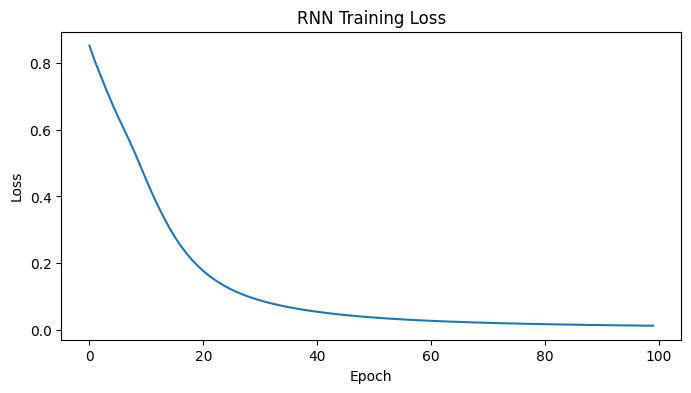

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training Loss")
plt.show()

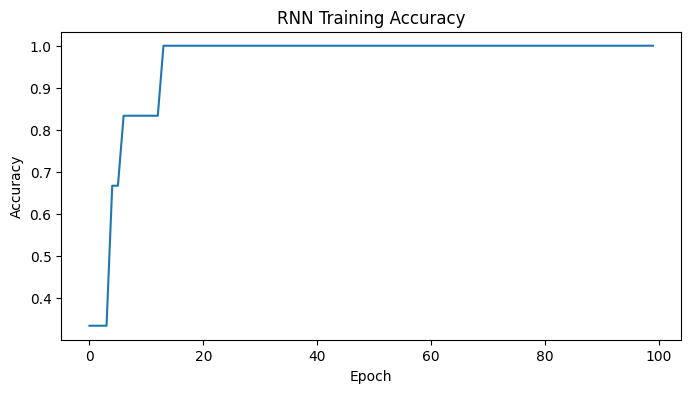

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training Accuracy")
plt.show()

In [20]:
hidden_sequence_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(timesteps, input_features)),
    tf.keras.layers.SimpleRNN(
        hidden_units,
        activation="tanh",
        return_sequences=True
    ),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

hidden_sequence_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

hidden_sequence_model.predict(X[:1], verbose=0).shape

(1, 3, 1)

In [21]:
sample_prediction = hidden_sequence_model.predict(X[:1], verbose=0)
sample_prediction

array([[[0.553275  ],
        [0.44779298],
        [0.51709926]]], dtype=float32)

In [22]:
embedding_dim = 16

integer_X = np.array(
    [
        [vocab[word] + 1 for word in review]
        for review in reviews
    ],
    dtype=np.int32
)

integer_X

array([[1, 3, 2],
       [1, 4, 2],
       [5, 3, 1],
       [1, 5, 4],
       [3, 1, 2],
       [4, 1, 2]], dtype=int32)

In [23]:
practical_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(timesteps,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embedding_dim
    ),
    tf.keras.layers.SimpleRNN(8),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

practical_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

practical_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 3, 16)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
practical_history = practical_model.fit(
    integer_X,
    labels,
    epochs=100,
    batch_size=2,
    verbose=0
)

practical_model.evaluate(integer_X, labels, verbose=0)

[0.06857771426439285, 1.0]

In [25]:
new_reviews = [
    ["movie", "good", "actor"],
    ["movie", "bad", "actor"],
    ["not", "good", "movie"],
    ["movie", "not", "bad"]
]

new_X = np.array(
    [
        [vocab[word] + 1 for word in review]
        for review in new_reviews
    ],
    dtype=np.int32
)

new_predictions = practical_model.predict(new_X, verbose=0).reshape(-1)

for review, prediction in zip(new_reviews, new_predictions):
    print(
        " ".join(review),
        "| probability =", round(float(prediction), 4),
        "| predicted =", int(prediction >= 0.5)
    )

movie good actor | probability = 0.9177 | predicted = 1
movie bad actor | probability = 0.0696 | predicted = 0
not good movie | probability = 0.9583 | predicted = 1
movie not bad | probability = 0.0609 | predicted = 0


In [26]:
rnn_parameter_formula = (
    input_features * hidden_units
    + hidden_units * hidden_units
    + hidden_units
    + hidden_units * 1
    + 1
)

rnn_parameter_formula

31

In [27]:
manual_parameter_table = {
    "Input-to-hidden weights": W_xh.size,
    "Hidden-to-hidden weights": W_hh.size,
    "Hidden bias": b_h.size,
    "Hidden-to-output weights": W_hy.size,
    "Output bias": b_y.size,
    "Total": total_parameters
}

manual_parameter_table

{'Input-to-hidden weights': 15,
 'Hidden-to-hidden weights': 9,
 'Hidden bias': 3,
 'Hidden-to-output weights': 3,
 'Output bias': 1,
 'Total': 31}

In [28]:
tf.saved_model.save(practical_model, "rnn_sentiment_model")

In [29]:
sample_text = ["movie", "not", "bad"]

sample_encoded = np.array(
    [[vocab[word] + 1 for word in sample_text]],
    dtype=np.int32
)

sample_probability = practical_model.predict(
    sample_encoded,
    verbose=0
)[0, 0]

print(float(sample_probability))
print(int(sample_probability >= 0.5))

0.06091845780611038
0
